Import modules

In [ ]:
import sys
sys.path.insert(0, '../') 
import data_generation_functions.SimulatorWaveEquation as simu
import numpy as np
from data_generation import DataPlotter as dp
import matplotlib.pyplot as plt
import GNN_model.GNN as gnn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import torch.nn as nn
import pytorch_lightning as pl

Set up data initializations

In [2]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 20 # Maximum degree of spherical harmonics 
generations = 3 # level of refinement for the grid
A = 1 # Amplitude of gaussian hill
sigma_deg = 15 # angular width of the hill
sigma = np.deg2rad(sigma_deg)

# Computing dt using formula derived in slides
omega_max = (C / R) * np.sqrt(Lmax * (Lmax + 1))
T_min = 2 * np.pi / omega_max
dt = T_min / 20
tmax = dt*1000

x0,y0,z0 = R,0,0 # Initial position of the gaussian hill 

# Initial condition: Gaussian hill centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

Simulate data

In [3]:
# data class
sim = simu.SimulatorWaveEquation(
    R=R,
    C=C,
    Lmax=Lmax,
    tmax=tmax,
    f_handle=f_handle,  
    g_handle=g_handle,  
    generations=generations,
    dt=dt,
)

ds = sim.simulate(title = None, savedata=False)
print(f"number of grid points: N = {sim.N}")
print(f"dt = {dt}")
print(f"dx = {sim.dx_true}")
print(f"cfl: {sim.cfl_value}")
print(f"number of data points in total:",len(ds["time"]))
print(f"final time:",tmax)

number of grid points: N = 642
dt = 0.015329402499064277
dx = 0.04140430782935302
cfl: 0.3702368981083825
number of data points in total: 1001
final time: 15.329402499064276


Set up and train model

In [4]:
dataset = gnn.WaveData(ds)

loader = PyGDataLoader(dataset, batch_size=1, shuffle=True)

Fin = 1
Fm = 64

phi = nn.Sequential(
    nn.Linear(2 * Fin, Fm),
    nn.ReLU(),
    nn.Linear(Fm, Fm),
)

psi = nn.Sequential(
    nn.Linear(Fin + Fm, Fm),
    nn.ReLU(),
    nn.Linear(Fm, Fin),
)

model = gnn.GNNModel(phi=phi, psi=psi, aggregate="mean", lr=1e-3)

metrics_logger = gnn.MetricsLogger()


In [5]:
trainer = pl.Trainer(max_epochs=5,callbacks=[metrics_logger])  
trainer.fit(model, loader) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Epoch 1: train loss = 0.0061

Epoch 2: train loss = 0.0061

Epoch 3: train loss = 0.0061

Epoch 4: train loss = 0.0061

`Trainer.fit` stopped: `max_epochs=5` reached.


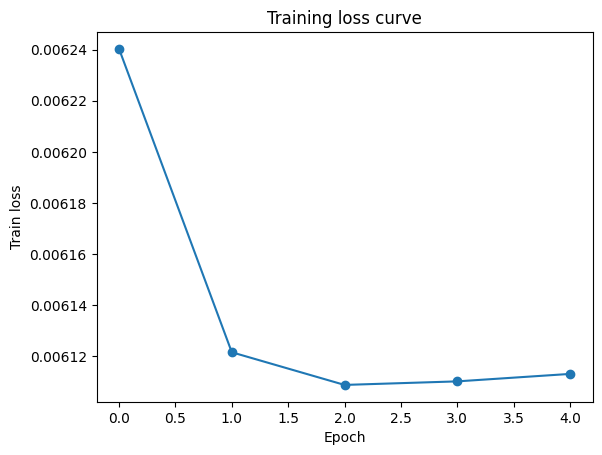

In [6]:
plt.plot(metrics_logger.train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss curve")
plt.show()